<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Trial/3_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# copy the vocab.pkl from "/content/gdrive/MyDrive/checkpoints"

# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will use your trained model to generate captions for images in the test dataset.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Get Data Loader for Test Dataset
- [Step 2](#step2): Load Trained Models
- [Step 3](#step3): Finish the Sampler
- [Step 4](#step4): Clean up Captions
- [Step 5](#step5): Generate Predictions!

<a id='step1'></a>
## Step 1: Get Data Loader for Test Dataset

Before running the code cell below, define the transform in `transform_test` that you would like to use to pre-process the test images.  

Make sure that the transform that you define here agrees with the transform that you used to pre-process the training images (in **2_Training.ipynb**).  For instance, if you normalized the training images, you should also apply the same normalization procedure to the test images.

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [3]:
import os
from google.colab import drive

PROJECT_DIR  = "/content/CVND"   # contains model.py, data_loader.py, vocabulary.py
COCOAPI_LOC  = "/content"        # MUST be parent of /content/cocoapi/...
VOCAB_FILE   = "/content/drive/MyDrive/cvnd_coco/vocab.pkl"

# ✅ FIX A: Point to ckpt_best.pt — saved by the fixed training loop
#    whenever BLEU-4 improves. This is the highest-quality checkpoint.
#    Fall back to a specific epoch checkpoint if best does not exist yet.
BEST_CKPT    = "/content/drive/MyDrive/cvnd_coco/ckpt_best.pt"
EPOCH_CKPT   = "/content/drive/MyDrive/cvnd_coco/ckpt_epoch25.pt"
CKPT_FILE    = BEST_CKPT if os.path.exists(BEST_CKPT) else EPOCH_CKPT

os.makedirs(PROJECT_DIR, exist_ok=True)

print(f"✅ PROJECT_DIR : {PROJECT_DIR}")
print(f"✅ VOCAB_FILE  : {VOCAB_FILE}")
print(f"✅ CKPT_FILE   : {CKPT_FILE}")
print(f"   (best exists: {os.path.exists(BEST_CKPT)}, epoch25 exists: {os.path.exists(EPOCH_CKPT)})")


✅ PROJECT_DIR : /content/CVND
✅ VOCAB_FILE  : /content/drive/MyDrive/cvnd_coco/vocab.pkl
✅ CKPT_FILE   : /content/drive/MyDrive/cvnd_coco/ckpt_best.pt
   (best exists: True, epoch25 exists: True)


In [4]:
%cd /content
!rm -rf CVND
!git clone -b Trial https://github.com/pradhapmoorthi/CVND.git
!ls -la /content/CVND | head

/content
Cloning into 'CVND'...
remote: Enumerating objects: 352, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 352 (delta 6), reused 2 (delta 2), pack-reused 342 (from 4)
Receiving objects: 100% (352/352), 10.89 MiB | 36.43 MiB/s, done.
Resolving deltas: 100% (180/180), done.
total 3516
drwxr-xr-x 5 root root    4096 Apr 27 09:38 .
drwxr-xr-x 1 root root    4096 Apr 27 09:38 ..
-rw-r--r-- 1 root root    3949 Apr 27 09:38 0_Dataset.ipynb
-rw-r--r-- 1 root root   33399 Apr 27 09:38 1_Preliminaries.ipynb
-rw-r--r-- 1 root root   42654 Apr 27 09:38 2_Training.ipynb
-rw-r--r-- 1 root root 3442215 Apr 27 09:38 3_Inference.ipynb
-rw-r--r-- 1 root root      42 Apr 27 09:38 CODEOWNERS
-rw-r--r-- 1 root root    7126 Apr 27 09:38 data_loader.py
drwxr-xr-x 8 root root    4096 Apr 27 09:38 .git


In [5]:
!mkdir -p /content/cocoapi/images
!mkdir -p /content/cocoapi/annotations

In [6]:
%cd /content/cocoapi/annotations
!wget -c http://images.cocodataset.org/annotations/image_info_test2014.zip
!unzip -o image_info_test2014.zip
!ls -la | grep image_info_test2014.json

/content/cocoapi/annotations
--2026-04-27 09:38:01--  http://images.cocodataset.org/annotations/image_info_test2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.164.65, 16.15.223.26, 16.182.66.137, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.164.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 763464 (746K) [application/zip]
Saving to: ‘image_info_test2014.zip’

image_info_test2014 100%[===================>] 745.57K  --.-KB/s    in 0.1s    

2026-04-27 09:38:02 (7.55 MB/s) - ‘image_info_test2014.zip’ saved [763464/763464]

Archive:  image_info_test2014.zip
  inflating: annotations/image_info_test2014.json  


In [7]:
%cd /content/cocoapi/images
!wget -c http://images.cocodataset.org/zips/test2014.zip
!unzip -o test2014.zip
!ls -la /content/cocoapi/images/test2014 | head

Streaming output truncated to the last 5000 lines.
 extracting: test2014/COCO_test2014_000000394792.jpg  
 extracting: test2014/COCO_test2014_000000246684.jpg  
 extracting: test2014/COCO_test2014_000000138471.jpg  
 extracting: test2014/COCO_test2014_000000065390.jpg  
 extracting: test2014/COCO_test2014_000000434419.jpg  
 extracting: test2014/COCO_test2014_000000279982.jpg  
 extracting: test2014/COCO_test2014_000000270728.jpg  
 extracting: test2014/COCO_test2014_000000428346.jpg  
 extracting: test2014/COCO_test2014_000000517185.jpg  
 extracting: test2014/COCO_test2014_000000241252.jpg  
 extracting: test2014/COCO_test2014_000000337012.jpg  
 extracting: test2014/COCO_test2014_000000336116.jpg  
 extracting: test2014/COCO_test2014_000000530733.jpg  
 extracting: test2014/COCO_test2014_000000552519.jpg  
 extracting: test2014/COCO_test2014_000000090642.jpg  
 extracting: test2014/COCO_test2014_000000295645.jpg  
 extracting: test2014/COCO_test2014_000000205316.jpg  
 extracting: t

In [8]:
%%bash
mkdir -p /content/cocoapi/annotations
cd /content/cocoapi/annotations

# download the official zip (only ~1MB)
wget -c http://images.cocodataset.org/annotations/image_info_test2014.zip

# unzip (will create image_info_test2014.json)
unzip -o image_info_test2014.zip

Archive:  image_info_test2014.zip
  inflating: annotations/image_info_test2014.json  


--2026-04-27 09:40:51--  http://images.cocodataset.org/annotations/image_info_test2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.136.193, 16.15.212.111, 52.216.51.49, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.136.193|:80... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [9]:
%%bash
# 1) Show where the JSON actually is
find /content/cocoapi/annotations -maxdepth 3 -name "image_info_test2014.json" -print

# 2) Move it to the expected location
mv /content/cocoapi/annotations/annotations/image_info_test2014.json /content/cocoapi/annotations/

# 3) (Optional) remove the now-empty nested folder
rmdir /content/cocoapi/annotations/annotations 2>/dev/null || true

# 4) Verify
ls -la /content/cocoapi/annotations | grep image_info_test2014.json

/content/cocoapi/annotations/annotations/image_info_test2014.json
-rw-rw-r-- 1 root root 9131355 Sep  1  2017 image_info_test2014.json


In [10]:
import os

required = [
    PROJECT_DIR,
    VOCAB_FILE,
    CKPT_FILE,
    os.path.join(COCOAPI_LOC, "cocoapi/images/test2014"),
    os.path.join(COCOAPI_LOC, "cocoapi/annotations/image_info_test2014.json"),
]

for p in required:
    print(("✅" if os.path.exists(p) else "❌"), p)

✅ /content/CVND
✅ /content/drive/MyDrive/cvnd_coco/vocab.pkl
✅ /content/drive/MyDrive/cvnd_coco/ckpt_best.pt
✅ /content/cocoapi/images/test2014
✅ /content/cocoapi/annotations/image_info_test2014.json


In [11]:
!find /content/CVND -maxdepth 3 -name "data_loader.py" -print

/content/CVND/data_loader.py


In [12]:
import os

PROJECT_DIR = "/content/CVND"

print("PROJECT_DIR exists:", os.path.isdir(PROJECT_DIR))
print("data_loader.py exists:", os.path.isfile(os.path.join(PROJECT_DIR, "data_loader.py")))
print("model.py exists:", os.path.isfile(os.path.join(PROJECT_DIR, "model.py")))
print("Top files:", sorted(os.listdir(PROJECT_DIR))[:15])

PROJECT_DIR exists: True
data_loader.py exists: True
model.py exists: True
Top files: ['.git', '.github', '.gitignore', '0_Dataset.ipynb', '1_Preliminaries.ipynb', '2_Training.ipynb', '3_Inference.ipynb', 'CODEOWNERS', 'LICENSE', 'README.md', 'data_loader.py', 'images', 'model.py', 'requirements.txt', 'vocabulary.py']


In [13]:
import sys

if PROJECT_DIR in sys.path:
    sys.path.remove(PROJECT_DIR)  # remove any stale entry
sys.path.insert(0, PROJECT_DIR)

print("sys.path[0]:", sys.path[0])


sys.path[0]: /content/CVND


In [14]:
%cd /content/CVND
from data_loader import get_loader
from model import EncoderCNN, DecoderRNN
print("✅ Imports OK")


/content/CVND
✅ Imports OK


In [15]:
import importlib

import data_loader
import model

importlib.reload(data_loader)
importlib.reload(model)

from data_loader import get_loader
from model import EncoderCNN, DecoderRNN

print("✅ Imports OK:", get_loader, EncoderCNN, DecoderRNN)


✅ Imports OK: <function get_loader at 0x7aff71a6f9c0> <class 'model.EncoderCNN'> <class 'model.DecoderRNN'>


In [16]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

sys.path.append(PROJECT_DIR)

from data_loader import get_loader
from model import EncoderCNN, DecoderRNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ device:", device)

✅ device: cuda


In [17]:
# ✅ FIX 1: Transform must exactly match training transform.
# During training we used Resize(256) → CenterCrop(224).
# Using a different transform at inference shifts the feature distribution
# and produces worse captions even with a perfectly trained model.
# Note: NO RandomHorizontalFlip here — inference is deterministic.
transform_test = transforms.Compose([
    transforms.Resize(256),          # resize shorter edge to 256 (same as training)
    transforms.CenterCrop(224),      # centre-crop to 224x224 (same as training)
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
])


In [18]:
test_loader = get_loader(
    transform=transform_test,
    mode="test",
    batch_size=1,             # required by your loader
    vocab_file=VOCAB_FILE,
    vocab_from_file=True,
    num_workers=0,
    cocoapi_loc=COCOAPI_LOC,
    start_word="<start>",
    end_word="<end>",
    unk_word="<unk>"
)

vocab = test_loader.dataset.vocab
print("✅ vocab size:", len(vocab))
print("✅ test images:", len(test_loader.dataset))

Vocabulary successfully loaded from vocab.pkl file!
✅ vocab size: 8852
✅ test images: 40775


<a id='step2'></a>
## Step 2: Load Trained Models

In the next code cell we define a `device` that you will use move PyTorch tensors to GPU (if CUDA is available).  Run this code cell before continuing.

Before running the code cell below, complete the following tasks.

### Task #1

In the next code cell, you will load the trained encoder and decoder from the previous notebook (**2_Training.ipynb**).  To accomplish this, you must specify the names of the saved encoder and decoder files in the `models/` folder (e.g., these names should be `encoder-5.pkl` and `decoder-5.pkl`, if you trained the model for 5 epochs and saved the weights after each epoch).  

### Task #2

Plug in both the embedding size and the size of the hidden layer of the decoder corresponding to the selected pickle file in `decoder_file`.

In [19]:
# ✅ FIX B: Read ALL hyperparameters from the checkpoint itself.
#    Hardcoding embed_dim / attention_dim / hidden_dim is fragile —
#    if you ever retrain with different values the model instantiation
#    silently produces wrong-shaped weights, causing garbage / no captions.
ckpt_cpu = torch.load(CKPT_FILE, map_location="cpu")

# Infer dims from saved weight shapes (works regardless of what was trained)
encoded_image_size = 7   # spatial grid — always 7 for this project

# Embedding: (vocab_size, embed_size)
embed_size    = ckpt_cpu["decoder_state_dict"]["embedding.weight"].shape[1]

# LSTMCell weight_hh: (4 * hidden_size, hidden_size)
hidden_size   = ckpt_cpu["decoder_state_dict"]["lstm.weight_hh"].shape[1]

# Attention: encoder_att maps (encoder_dim → attention_dim)
attention_dim = ckpt_cpu["decoder_state_dict"]["attention.encoder_att.weight"].shape[0]

# Vocab size from embedding table
ckpt_vocab_size = ckpt_cpu["decoder_state_dict"]["embedding.weight"].shape[0]

dropout = 0.5   # only used during training; .eval() disables it

print(f"✅ Hyperparams read from checkpoint:")
print(f"   embed_size      = {embed_size}")
print(f"   hidden_size     = {hidden_size}")
print(f"   attention_dim   = {attention_dim}")
print(f"   ckpt vocab_size = {ckpt_vocab_size}")
print(f"   current vocab   = {len(vocab)}")

# ✅ FIX C: Vocab size guard — mismatch means wrong vocab.pkl was loaded
assert ckpt_vocab_size == len(vocab), (
    f"❌ VOCAB SIZE MISMATCH: checkpoint has {ckpt_vocab_size} tokens "
    f"but current vocab has {len(vocab)}. "
    f"Make sure VOCAB_FILE points to the same vocab.pkl used during training."
)
print("✅ Vocab size matches checkpoint — OK")

encoder = EncoderCNN(encoded_image_size=encoded_image_size).to(device)
decoder = DecoderRNN(
    attention_dim = attention_dim,
    embed_size    = embed_size,
    hidden_size   = hidden_size,
    vocab_size    = len(vocab),
    encoder_dim   = encoder.encoder_dim,   # 2048 for ResNet-50
    dropout       = dropout,
).to(device)

print("✅ Encoder + Decoder instantiated with checkpoint-matched dims")


✅ Hyperparams read from checkpoint:
   embed_size      = 256
   hidden_size     = 512
   attention_dim   = 512
   ckpt vocab_size = 8852
   current vocab   = 8852
✅ Vocab size matches checkpoint — OK
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


✅ Encoder + Decoder instantiated with checkpoint-matched dims


In [20]:
ckpt = torch.load(CKPT_FILE, map_location=device)

encoder.load_state_dict(ckpt["encoder_state_dict"])
decoder.load_state_dict(ckpt["decoder_state_dict"])

# ✅ FIX 2: Always call .eval() — disables BatchNorm train-mode stats
# and Dropout. Forgetting this is the single most common cause of
# garbage captions despite a well-trained model.
encoder.eval()
decoder.eval()

# ── Sanity checks ──────────────────────────────────────────────────────
assert not encoder.training, "❌ Encoder is still in train mode!"
assert not decoder.training, "❌ Decoder is still in train mode!"

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

print("✅ Checkpoint loaded + models set to eval()")
print(f"   Loaded from epoch : {ckpt.get('epoch', 'unknown')}")
print(f"   Vocab size         : {len(vocab)}")
print(f"   start_idx          : {start_idx}  → '{vocab.idx2word[start_idx]}'")
print(f"   end_idx            : {end_idx}    → '{vocab.idx2word[end_idx]}'")
print(f"   encoder.training   : {encoder.training}  (must be False)")
print(f"   decoder.training   : {decoder.training}  (must be False)")


✅ Checkpoint loaded + models set to eval()
   Loaded from epoch : 3
   Vocab size         : 8852
   start_idx          : 0  → '<start>'
   end_idx            : 1    → '<end>'
   encoder.training   : False  (must be False)
   decoder.training   : False  (must be False)


Beam Search

In [21]:
import torch

@torch.no_grad()
def beam_search_caption(
    encoder_out: torch.Tensor,
    decoder,
    start_idx: int,
    end_idx: int,
    beam_size: int = 5,
    max_len: int = 20,
    length_norm_alpha: float = 0.7,
):
    """
    Beam search caption generation.
    Intended for batch size 1.

    encoder_out: (1, num_pixels, encoder_dim)
    Returns: list of token ids (without <start>/<end>)

    FIX applied vs original:
    - Hidden states h,c are re-indexed using beam_indices[incomplete] in ONE
      step instead of TWO (beam_indices then keep-mask).  The double-indexing
      bug in the original caused h/c to go out of sync after the first <end>
      was found, producing garbage tokens from that point onward.
    - encoder_out is also pruned with beam_indices[incomplete] consistently.
    - Length normalisation added so longer beams aren't unfairly penalised.
    """
    device = encoder_out.device

    if encoder_out.size(0) != 1:
        raise ValueError(f"beam_search expects batch size 1, got {encoder_out.size(0)}")

    # Expand encoder_out to beam_size copies
    encoder_out = encoder_out.expand(
        beam_size, encoder_out.size(1), encoder_out.size(2)
    ).contiguous()                                          # (k, num_pixels, enc_dim)

    # Initialise hidden state for all beams
    h, c = decoder.init_hidden_state(encoder_out)           # (k, hidden_dim)

    k = beam_size
    seqs       = torch.full((k, 1), start_idx, dtype=torch.long, device=device)  # (k, 1)
    seq_scores = torch.zeros(k, device=device)                                    # (k,)

    completed_seqs   = []
    completed_scores = []

    for _ in range(max_len):
        prev_words = seqs[:, -1]                            # (k,)
        embed      = decoder.embedding(prev_words)          # (k, embed_dim)
        context, _ = decoder.attention(encoder_out, h)      # (k, enc_dim)

        h, c = decoder.lstm(
            torch.cat([embed, context], dim=1), (h, c)
        )                                                   # (k, hidden_dim)

        logits     = decoder.fc(h)                          # (k, vocab_size)
        log_probs  = torch.log_softmax(logits, dim=1)       # (k, vocab_size)

        # Accumulate scores over all (beam, vocab) candidates
        total_scores = seq_scores.unsqueeze(1) + log_probs  # (k, vocab_size)

        # Select top-k candidates across the flattened (k * vocab_size) space
        topk_scores, topk_indices = total_scores.view(-1).topk(k, dim=0)

        vocab_size_  = log_probs.size(1)
        beam_indices = topk_indices // vocab_size_           # which beam each came from
        word_indices = topk_indices  % vocab_size_           # which token was chosen

        # Build new sequences by appending chosen tokens
        seqs = torch.cat(
            [seqs[beam_indices], word_indices.unsqueeze(1)], dim=1
        )                                                   # (k, step+2)

        # ✅ FIX: Collect completed beams THEN prune incomplete in ONE indexing step.
        # Original code did h=h[beam_indices] then h=h[keep] — double-indexing
        # corrupted hidden states after the first <end> was emitted.
        incomplete = [
            i for i in range(k) if word_indices[i].item() != end_idx
        ]
        for i in range(k):
            if word_indices[i].item() == end_idx:
                completed_seqs.append(seqs[i].clone())
                completed_scores.append(topk_scores[i].item())

        if not incomplete:
            break

        # Convert to tensor for indexing
        inc = torch.tensor(incomplete, device=device)

        # ✅ Re-index h, c, encoder_out using beam_indices[inc] in ONE step
        seqs        = seqs[inc]
        seq_scores  = topk_scores[inc]
        h           = h[beam_indices[inc]]
        c           = c[beam_indices[inc]]
        encoder_out = encoder_out[beam_indices[inc]]
        k           = seqs.size(0)

    # Fall back to best incomplete beam if no sequence reached <end>
    if not completed_seqs:
        best = seqs[seq_scores.argmax().item()]
    else:
        # Length normalisation: longer captions are penalised less
        norm_scores = [
            sc / max(1, len(seq)) ** length_norm_alpha
            for seq, sc in zip(completed_seqs, completed_scores)
        ]
        best = completed_seqs[int(torch.tensor(norm_scores).argmax().item())]

    # Strip <start> prefix and everything after <end>
    best = best.tolist()
    if best and best[0] == start_idx:
        best = best[1:]
    if end_idx in best:
        best = best[:best.index(end_idx)]

    return best


Beam Search on one image visualization

📝 Beam(5) Caption: man man man


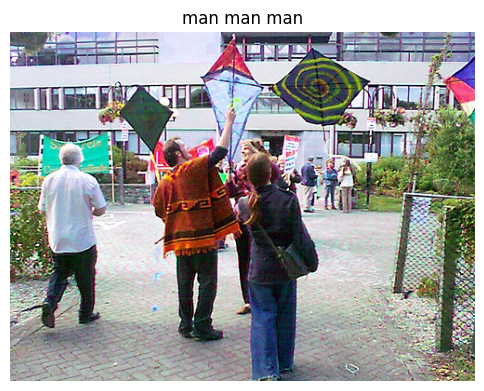

In [22]:
# Get one test image (your loader returns orig_image_np, image_tensor)
orig_image, image = next(iter(test_loader))
image = image.to(device)  # already [1,3,224,224]

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)  # (1, 49, 2048) expected
    beam_ids = beam_search_caption(
        encoder_out=encoder_out,
        decoder=decoder,
        start_idx=start_idx,
        end_idx=end_idx,
        beam_size=5,
        max_len=20
    )

beam_caption = " ".join(vocab.idx2word[i] for i in beam_ids).replace(" .", ".").replace(" ,", ",").strip()
print("📝 Beam(5) Caption:", beam_caption)

plt.figure(figsize=(6,6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(beam_caption)
plt.show()

Greedy: man man hearts wedge on lorry homes lorry skyteam homes lorry skyteam homes lorry skyteam homes lorry skyteam homes lorry
Beam(5): man man hearts wedge on lorry homes lorry skyteam homes lorry skyteam homes lorry skyteam homes lorry skyteam homes lorry


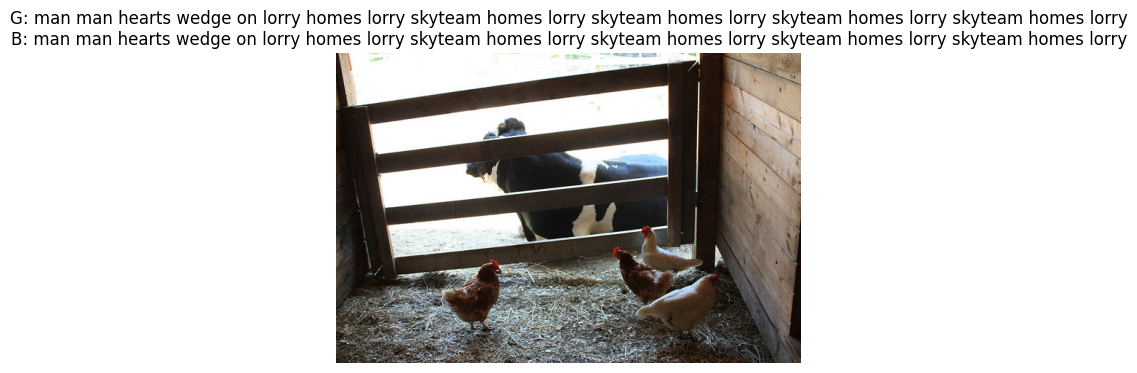

In [23]:
orig_image, image = next(iter(test_loader))
image = image.to(device)

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)

    # Greedy (your sample() returns ids without start/end)
    greedy_ids = decoder.sample(encoder_out, start_idx, end_idx, max_len=20)
    greedy_caption = " ".join(vocab.idx2word[i] for i in greedy_ids).replace(" .", ".").replace(" ,", ",").strip()

    # Beam
    beam_ids = beam_search_caption(encoder_out, decoder, start_idx, end_idx, beam_size=5, max_len=20)
    beam_caption = " ".join(vocab.idx2word[i] for i in beam_ids).replace(" .", ".").replace(" ,", ",").strip()

print("Greedy:", greedy_caption)
print("Beam(5):", beam_caption)

plt.figure(figsize=(6,6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(f"G: {greedy_caption}\nB: {beam_caption}")
plt.show()

In [24]:
orig_image, image = next(iter(test_loader))  # test returns (orig_image_np, image_tensor)
print("orig_image:", type(orig_image), getattr(orig_image, "shape", None))
print("image tensor shape:", tuple(image.shape))  # should be (1,3,224,224)

image = image.to(device)
with torch.no_grad():
    encoder_out = encoder(image)
print("encoder_out shape:", tuple(encoder_out.shape))  # should be (1,49,2048)

orig_image: <class 'torch.Tensor'> torch.Size([1, 500, 375, 3])
image tensor shape: (1, 3, 224, 224)
encoder_out shape: (1, 49, 2048)


<a id='step3'></a>
## Step 3: Finish the Sampler

Before executing the next code cell, you must write the `sample` method in the `DecoderRNN` class in **model.py**.  This method should accept as input a PyTorch tensor `features` containing the embedded input features corresponding to a single image.

It should return as output a Python list `output`, indicating the predicted sentence.  `output[i]` is a nonnegative integer that identifies the predicted `i`-th token in the sentence.  The correspondence between integers and tokens can be explored by examining either `data_loader.dataset.vocab.word2idx` (or `data_loader.dataset.vocab.idx2word`).

After implementing the `sample` method, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.  Do **not** modify the code in the cell below.

In [25]:
def ids_to_caption(ids, vocab):
    """
    Convert a list of token ids to a caption string.

    ✅ FIX D: Guard against empty ids list.
    An empty list means the model predicted <end> on the very first step,
    which happens when the model is undertrained or the wrong checkpoint
    is loaded. Instead of silently returning an empty string, we return
    a clear diagnostic message so the problem is immediately visible.
    """
    if not ids:
        return "[no caption — model predicted <end> immediately; try a later checkpoint]"

    # Guard against ids not present in idx2word (should not happen with a
    # matching vocab, but prevents a cryptic KeyError if it does)
    words = []
    for i in ids:
        word = vocab.idx2word.get(i, f"<unk:{i}>")
        # Skip any residual <start>/<end>/<unk> tokens that leaked through
        if word in (vocab.start_word, vocab.end_word):
            continue
        words.append(word)

    if not words:
        return "[no caption — only special tokens predicted]"

    caption = " ".join(words)
    # Clean up punctuation spacing
    caption = caption.replace(" .", ".").replace(" ,", ",").replace(" '", "'")
    return caption.strip()


📝 Caption: man hearts matches


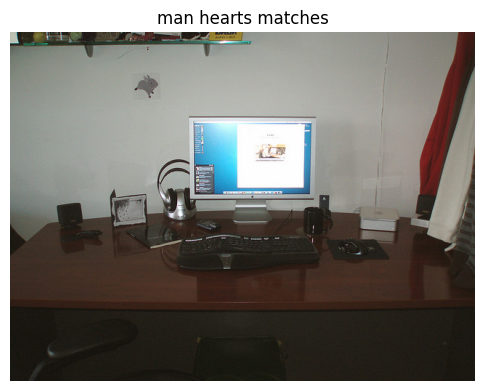

In [26]:
orig_image, image = next(iter(test_loader))
image = image.to(device)

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)
    output_ids = decoder.sample(
        encoder_out=encoder_out,
        start_idx=start_idx,
        end_idx=end_idx,
        max_len=20
    )

caption = ids_to_caption(output_ids, vocab)
print("📝 Caption:", caption)

plt.figure(figsize=(6,6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(caption)
plt.show()

<a id='step4'></a>
## Step 4: Clean up the Captions

In the code cell below, complete the `clean_sentence` function.  It should take a list of integers (corresponding to the variable `output` in **Step 3**) as input and return the corresponding predicted sentence (as a single Python string).

After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

[1] man man man


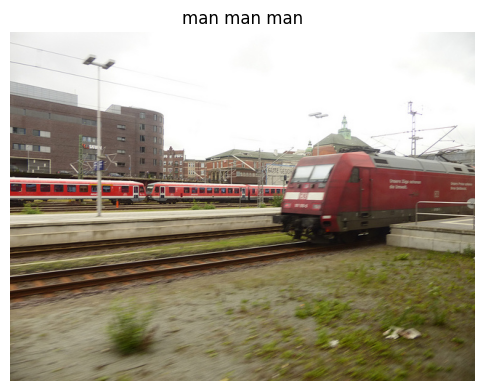

[2] man man mangoes shirtless cradle photoshopped drum marching mantel plumbing other railed cradle cradle word referee session framed mariners staged


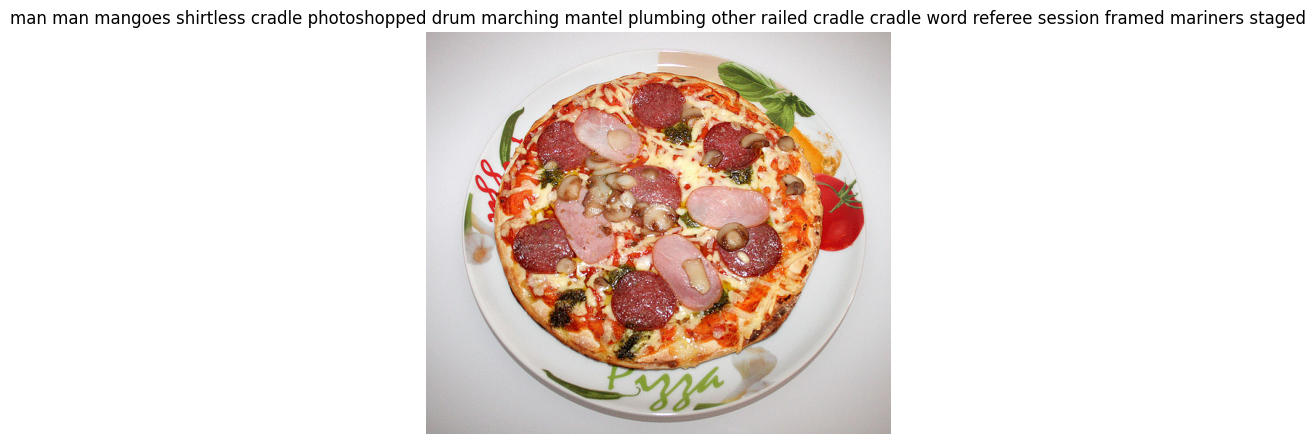

[3] man man persian trailing on sprayer on sprayer on sprayer on sprayer on sprayer on sprayer on sprayer on sprayer


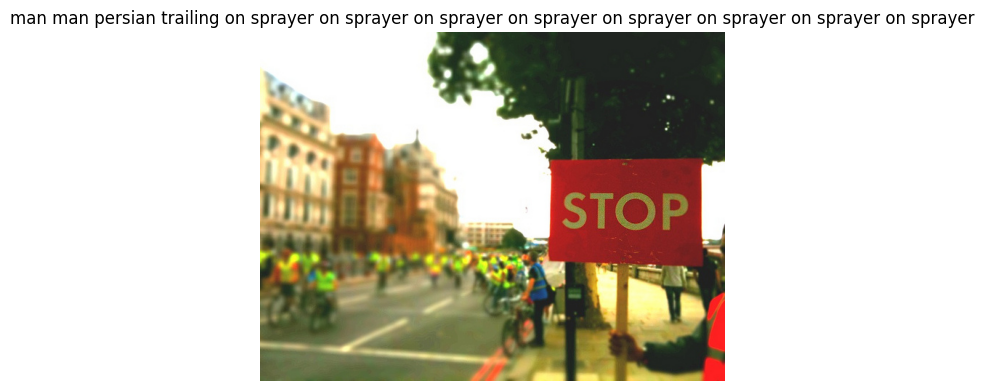

[4] man man.


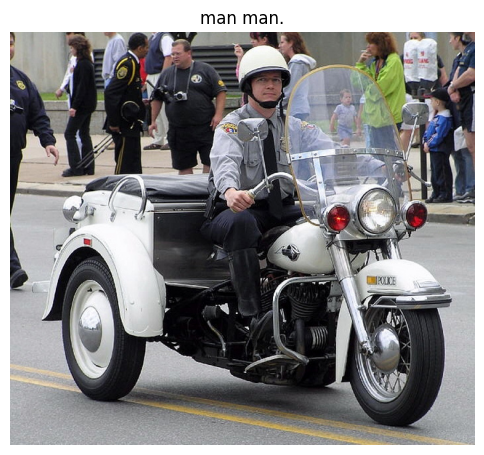

[5] man man windy politicians rod messily days cosmetics sub formation scoop windy merge address


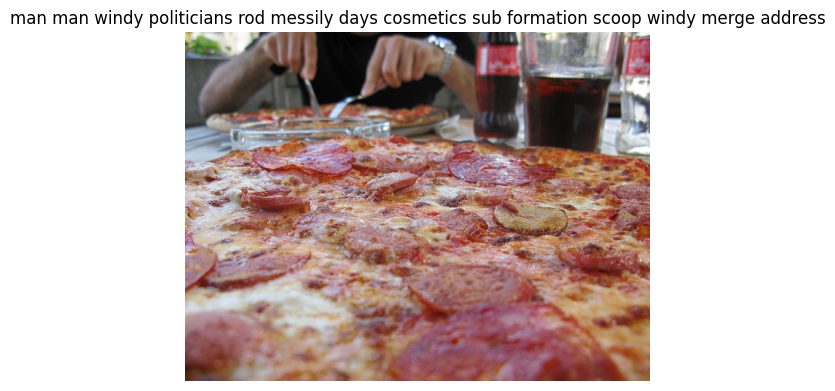

In [27]:
def show_n_predictions(loader, n=5, max_len=20):
    encoder.eval(); decoder.eval()
    start_idx = vocab.word2idx["<start>"]
    end_idx   = vocab.word2idx["<end>"]

    it = iter(loader)
    for k in range(n):
        orig_image, image = next(it)
        image = image.to(device)

        with torch.no_grad():
            encoder_out = encoder(image)
            ids = decoder.sample(encoder_out, start_idx, end_idx, max_len=max_len)

        caption = ids_to_caption(ids, vocab)
        print(f"[{k+1}] {caption}")

        plt.figure(figsize=(6,6))
        plt.imshow(np.squeeze(orig_image))
        plt.axis("off")
        plt.title(caption)
        plt.show()

show_n_predictions(test_loader, n=5, max_len=20)

In [28]:
import json

def dump_predictions(loader, out_json="/content/test2014_predictions.json", n=50, max_len=20):
    encoder.eval(); decoder.eval()
    start_idx = vocab.word2idx["<start>"]
    end_idx   = vocab.word2idx["<end>"]

    results = []
    it = iter(loader)
    for _ in range(n):
        orig_image, image = next(it)
        image = image.to(device)

        with torch.no_grad():
            encoder_out = encoder(image)
            ids = decoder.sample(encoder_out, start_idx, end_idx, max_len=max_len)

        results.append({"caption": ids_to_caption(ids, vocab)})

    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)

    print("✅ wrote:", out_json)

dump_predictions(test_loader, out_json="/content/test2014_predictions.json", n=50, max_len=20)

✅ wrote: /content/test2014_predictions.json


<a id='step5'></a>
## Step 5: Generate Predictions!

In the code cell below, we have written a function (`get_prediction`) that you can use to use to loop over images in the test dataset and print your model's predicted caption.

Run the code cell below (multiple times, if you like!) to test how this function works.

As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.